# Aula 08 - Aprendizado Supervisionado - Parte 2 (Classificação: Regressão Logística & KNN)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 07, aprendemos a prever números contínuos com a Regressão Linear. Mas a grande maioria das decisões de negócio envolve escolher entre classes: aprovar ou recusar, doente ou saudável, spam ou não-spam.
> 🎯 **Objetivo Principal da Aula:** Dominar os fundamentos da **Classificação Supervisionada**, treinando e comparando dois algoritmos clássicos (**Regressão Logística** e **K-Nearest Neighbors / KNN**), e interpretando o desempenho real do modelo através da **Matriz de Confusão** e das métricas de **Acurácia, Precisão, Recall e F1-Score**.
> 🚀 **Para onde vamos:** Na próxima aula ('Aprendizado Supervisionado - Parte 3'), descobriremos o que fazer quando as regras de decisão forem mais complexas do que retas ou vizinhanças: aprenderemos como a máquina constrói fluxogramas automáticos usando **Árvores de Decisão**, e como juntar centenas delas em uma **Random Forest**.

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & O Problema da Classificação** | A Função Sigmóide ($\sigma(z)$), a intuição geométrica do KNN e o conceito de Fronteira de Decisão. |
| **Módulo 2** | **Matriz de Confusão & Métricas de Avaliação** | Verdadeiro Positivo/Negativo, Falso Positivo/Negativo, Acurácia, Precisão, Recall e F1-Score. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 8 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Classificação de Tipos de Pokémon / Casas de Hogwarts com alteração de vizinhos $K$. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & O Paradigma da Classificação

### 1.1 Por que a Regressão Linear Falha em Problemas Categóricos?
Na Aula 07, vimos que a Regressão Linear projeta valores em uma linha reta sem limites ($-\infty$ a $+\infty$). Se tentássemos usá-la para prever se um paciente está *Doente (1)* ou *Saudável (0)*, ela produziria previsões inválidas como $-2.4$ ou $+3.8$.

A **Regressão Logística** passa a saída da reta por uma função de ativação chamada **Função Sigmóide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

A Sigmóide espreme qualquer número real estritamente para o intervalo entre **$0.0$ e $1.0$ (Probabilidade)**. Se $P \ge 0.50$, o modelo prevê a Classe 1; caso contrário, a Classe 0.

```mermaid
graph LR
    A["📐 SOMA PONDERADA z<br/>(-infinity a +infinity)"] --> B["🌀 FUNÇÃO SIGMÓIDE<br/>1 / (1 + e^-z)"]
    B --> C["🎲 PROBABILIDADE (0.0 a 1.0)<br/>Se P >= 0.50 -> Classe 1"]
```

> [!TIP]
> 🧙‍♂️ **Analogia Geek — O Chapéu Seletor de Hogwarts / Classificador Pokémon:**
> Pense no algoritmo KNN como o Chapéu Seletor de Harry Potter. Quando um novo estudante se senta na cadeira (nova amostra de dados), o Chapéu Seletor analisa as características das pessoas que sentam **mais perto dele na mesa** ($K$ vizinhos mais próximos). Se a maioria dos vizinhos próximos for da *Grifinória*, o aluno é enviado para a Grifinória!

> [!NOTE]
> 💡 **Curiosidade da Aula — A Origem da Função Sigmóide:**
> A curva matemática da Sigmóide (Curva Logística) foi criada em **1838 pelo matemático belga Pierre François Verhulst** para modelar o crescimento de populações humanas sujeitas a recursos limitados (comida, espaço). Décadas mais tarde, os estatísticos perceberam que a mesma curva curvada em "S" era perfeita para converter pontuações brutas em probabilidades de eventos binários em Machine Learning!  
> 🎥 **Vídeos Recomendados (StatQuest):**  
> 🔗 [StatQuest: Logistic Regression (YouTube)](https://www.youtube.com/watch?v=yIYKR4sgzI8) | [K-Nearest Neighbors (KNN) (YouTube)](https://www.youtube.com/watch?v=HVXime0nQeI)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** A Regressão Logística usa a função Sigmóide para converter qualquer valor numérico em uma probabilidade de 0.0 a 1.0 para classificar categorias.

---

## Módulo 2: O Mecanismo por Dentro & Matriz de Confusão

### 2.1 Entendendo a Matriz de Confusão (2x2)

```
                       VALOR REAL (Gabarito)
                   │  Positivo (1)  │  Negativo (0)  │
 ─── PREVISÃO ────┼────────────────┼────────────────┤
   Positivo (1)   │      VP        │      FP        │  (FP = Alarme Falso)
   Negativo (0)   │      FN        │      VN        │  (FN = Erro Perigoso!)
```

### 2.2 As 4 Métricas Formais de Classificação

- **Acurácia:** Porcentagem geral de acertos. $\frac{VP + VN}{VP + VN + FP + FN}$
- **Precisão:** De tudo que o modelo previu como Positivo, quanto realmente era Positivo? $\frac{VP}{VP + FP}$
- **Recall (Sensibilidade):** De todos os casos reais Positivos, quantos o modelo conseguiu detectar? $\frac{VP}{VP + FN}$
- **F1-Score:** A média harmônica equilibrada entre Precisão e Recall. $2 \times \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão} + \text{Recall}}$

> [!IMPORTANT]
> 💡 **Em 1 Frase:** A Matriz de Confusão detalha os acertos (VP/VN) e erros (FP/FN) do modelo, permitindo avaliar se a IA está cometendo alarmes falsos ou omitindo casos graves.

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** esta aula reutiliza o fluxo da regressão: separar dados, treinar, prever e avaliar. A diferença é que agora a resposta é uma classe, como “cliente aprovável” ou “não aprovável”. Regressão Logística, KNN e matriz de confusão são primeiros contatos; comece entendendo a pergunta que cada etapa responde.

---

### Bloco 3.1 — Importação de Bibliotecas para Classificação

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Para que servem os módulos importados do `sklearn.metrics`?**  
> `accuracy_score` calcula a taxa de acerto global; `confusion_matrix` gera a tabela 2x2 de acertos/erros; `classification_report` gera um resumo completo contendo Precisão, Recall e F1-Score.

In [1]:
# 1. Importamos as bibliotecas fundamentais de manipulação e gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos as funções de pré-processamento e divisão do Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 3. Importamos os dois classificadores supervisionados da aula (Regressão Logística e KNN)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 4. Importamos as métricas de avaliação para classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 5. Exibimos a mensagem de confirmação
print("--- CHECAGEM DE AMBIENTE DE CLASSIFICAÇÃO ---")
print("✅ Bibliotecas de classificação carregadas com sucesso!")

--- CHECAGEM DE AMBIENTE DE CLASSIFICAÇÃO ---
✅ Bibliotecas de classificação carregadas com sucesso!


---

### Bloco 3.2 — Gerando Dataset Bancário Simulado (Renda e Score)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significa a variável `aprovado` ser 0 ou 1?**  
> Significa que este é um problema de **Classificação Binária**: $1$ representa crédito aprovado para o cliente e $0$ representa crédito recusado.

In [2]:
# 1. Travamos a semente aleatória para garantir resultados idênticos para toda a sala
np.random.seed(42)

# 2. Sorteamos 100 rendas de clientes (entre 2 e 15 mil reais) e 100 scores de crédito (300 a 850)
renda_milhares = np.random.uniform(2, 15, size=100)
score_credito = np.random.uniform(300, 850, size=100)

# 3. Criamos a regra sintética binária: 1 se aprovado no crédito, 0 se recusado
credito_aprovado = ((0.4 * renda_milhares + 0.008 * score_credito - 7) >= 0).astype(int)

# 4. Montamos o DataFrame do banco
tabela_banco = pd.DataFrame({'renda_k': renda_milhares, 'score': score_credito, 'aprovado': credito_aprovado})

# 5. Exibimos os primeiros registros
print("--- DATASET BANCÁRIO DE CRÉDITO SIMULADO ---")
print(f"📐 Dimensão: {tabela_banco.shape[0]} registros x {tabela_banco.shape[1]} colunas")
print("\nPrimeiras 5 linhas:")
print(tabela_banco.head())

--- DATASET BANCÁRIO DE CRÉDITO SIMULADO ---
📐 Dimensão: 100 registros x 3 colunas

Primeiras 5 linhas:
     renda_k       score  aprovado
0   6.869022  317.286052         0
1  14.359286  650.025726         1
2  11.515921  472.895790         1
3   9.782560  579.713880         1
4   4.028242  799.161561         1


---

### Bloco 3.3 — Divisão Treino e Teste com Estratificação de Classes

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que usamos `stratify=vetor_respostas_y` no `train_test_split`?**  
> O `stratify` garante que a porcentagem de aprovados ($1$) e recusados ($0$) seja **exatamente a mesma** tanto no conjunto de treino quanto no conjunto de teste, evitando desequilíbrios.

In [3]:
# 1. Isolamos a matriz de entrada X (renda e score) e o vetor de respostas y (aprovado)
matriz_entradas_x = tabela_banco[['renda_k', 'score']].values
vetor_respostas_y = tabela_banco['aprovado'].values

# 2. Dividimos em 75% para treino e 25% para teste ativando o stratify
matriz_entradas_treino, matriz_entradas_teste, vetor_respostas_treino, vetor_respostas_teste = train_test_split(
    matriz_entradas_x, 
    vetor_respostas_y, 
    test_size=0.25, 
    random_state=42, 
    stratify=vetor_respostas_y
)

# 3. Exibimos a contagem de amostras
print("--- DIVISÃO DE DADOS (COM ESTRATIFICAÇÃO) ---")
print(f"📦 Amostras para TREINAR: {len(matriz_entradas_treino)}")
print(f"🧪 Amostras para TESTAR:  {len(matriz_entradas_teste)}")

--- DIVISÃO DE DADOS (COM ESTRATIFICAÇÃO) ---
📦 Amostras para TREINAR: 75
🧪 Amostras para TESTAR:  25


---

### Bloco 3.4 — Padronização dos Dados (`StandardScaler`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que a padronização de escala é OBRIGATÓRIA para o KNN?**  
> Porque o KNN calcula a **distância geométrica** (Euclidiana) entre os pontos. Como o `score` varia de 300 a 850 e a `renda` varia de 2 a 15, sem o `StandardScaler` o modelo ignoraria a renda totalmente!

In [4]:
# 1. Instanciamos o padronizador de escala
escalonador_padronizado = StandardScaler()

# 2. Calculamos a escala nos dados de treino e transformamos os dados de treino
matriz_treino_padronizada = escalonador_padronizado.fit_transform(matriz_entradas_treino)

# 3. Aplicamos a mesma escala calculada aos dados de teste
matriz_teste_padronizada = escalonador_padronizado.transform(matriz_entradas_teste)

# 4. Exibimos confirmação no console
print("--- PADRONIZAÇÃO DE ESCALA ---")
print("✅ Dados de treino e teste padronizados com sucesso com Média = 0 e Desvio Padrão = 1!")

--- PADRONIZAÇÃO DE ESCALA ---
✅ Dados de treino e teste padronizados com sucesso com Média = 0 e Desvio Padrão = 1!


---

### Bloco 3.5 — Treinando a Regressão Logística (`fit`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como a Regressão Logística decide a classe final?**  
> Ela calcula a probabilidade $P$ via Sigmóide. Se $P \ge 0.50$, o modelo atribui a classe $1$ (Crédito Aprovado); caso contrário, atribui $0$.

In [5]:
# 1. Instanciamos a Regressão Logística com semente fixa
modelo_regressao_logistica = LogisticRegression(random_state=42)

# 2. O MOMENTO DO APRENDIZADO: O modelo ajusta os pesos da curva Sigmóide nos dados de treino
modelo_regressao_logistica.fit(matriz_treino_padronizada, vetor_respostas_treino)

# 3. Geramos previsões para o conjunto de teste padronizado
previsoes_logistica_teste = modelo_regressao_logistica.predict(matriz_teste_padronizada)

# 4. Calculamos a acurácia global do modelo logístico
acuracia_logistica = accuracy_score(vetor_respostas_teste, previsoes_logistica_teste)

# 5. Exibimos a acurácia no console
print("--- REGRESSÃO LOGÍSTICA TREINADA ---")
print(f"📊 Acurácia nos Dados de Teste: {acuracia_logistica * 100:.2f}%")

--- REGRESSÃO LOGÍSTICA TREINADA ---
📊 Acurácia nos Dados de Teste: 92.00%


---

### Bloco 3.6 — Treinando o K-Nearest Neighbors (KNN com K=5)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significa o parâmetro `n_neighbors=5`?**  
> Significa que ao receber uma nova pessoa para classificar, o algoritmo buscará os **5 clientes mais próximos** no gráfico e fará uma votação da maioria.

In [6]:
# 1. Instanciamos o classificador KNN configurado para 5 vizinhos
modelo_knn_vizinhos = KNeighborsClassifier(n_neighbors=5)

# 2. O MOMENTO DO APRENDIZADO: O KNN armazena os pontos padronizados no espaço geométrico
modelo_knn_vizinhos.fit(matriz_treino_padronizada, vetor_respostas_treino)

# 3. Geramos previsões por votação de vizinhos nos dados de teste
previsoes_knn_teste = modelo_knn_vizinhos.predict(matriz_teste_padronizada)

# 4. Calculamos a acurácia do KNN
acuracia_knn = accuracy_score(vetor_respostas_teste, previsoes_knn_teste)

# 5. Exibimos o resultado
print("--- CLASSIFICADOR KNN (K=5) TREINADO ---")
print(f"📊 Acurácia KNN (K=5) nos Dados de Teste: {acuracia_knn * 100:.2f}%")

--- CLASSIFICADOR KNN (K=5) TREINADO ---
📊 Acurácia KNN (K=5) nos Dados de Teste: 92.00%


---

### Bloco 3.7 — Gerando e Interpretando a Matriz de Confusão

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Qual o significado de cada número na Matriz de Confusão 2x2?**  
> - **VP `[1, 1]`:** Aprovados que eram realmente Aprovados.  
> - **VN `[0, 0]`:** Recusados que eram realmente Recusados.  
> - **FP `[0, 1]`:** Falso Alarme (Pessoas recusadas que o modelo aprovou por engano).  
> - **FN `[1, 0]`:** Erro Grave (Pessoas aprovadas que o modelo recusou por engano).

In [7]:
# 1. Geramos a matriz de confusão comparando o gabarito real com as previsões do KNN
matriz_confusao_knn = confusion_matrix(vetor_respostas_teste, previsoes_knn_teste)

# 2. Extraímos as quatro células da matriz 2x2
verdadeiro_positivo = matriz_confusao_knn[1, 1] # VP
verdadeiro_negativo = matriz_confusao_knn[0, 0] # VN
falso_positivo = matriz_confusao_knn[0, 1]      # FP
falso_negativo = matriz_confusao_knn[1, 0]      # FN

# 3. Exibimos a interpretação didática no console
print("--- MATRIZ DE CONFUSÃO DETALHADA (KNN) ---")
print(matriz_confusao_knn)
print(f"\n✅ Verdadeiros Positivos (VP - Aprovados corretos):  {verdadeiro_positivo}")
print(f"✅ Verdadeiros Negativos (VN - Recusados corretos):   {verdadeiro_negativo}")
print(f"⚠️ Falsos Positivos (FP - Alarme Falso de Crédito):   {falso_positivo}")
print(f"🚨 Falsos Negativos (FN - Erro de Risco Financeiro):  {falso_negativo}")

--- MATRIZ DE CONFUSÃO DETALHADA (KNN) ---
[[ 8  0]
 [ 2 15]]

✅ Verdadeiros Positivos (VP - Aprovados corretos):  15
✅ Verdadeiros Negativos (VN - Recusados corretos):   8
⚠️ Falsos Positivos (FP - Alarme Falso de Crédito):   0
🚨 Falsos Negativos (FN - Erro de Risco Financeiro):  2


---

### Bloco 3.8 — Relatório Completo de Métricas (`classification_report`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que o `classification_report` traz de especial?**  
> Ele exibe o raio-X completo do modelo, detalhando **Precisão**, **Recall** e **F1-Score** separadamente para a classe 0 (Recusados) e classe 1 (Aprovados).

In [8]:
# 1. Imprimimos o relatório completo de métricas gerado pelo Scikit-Learn
print("--- RELATÓRIO COMPLETO DE CLASSIFICAÇÃO (KNN) ---")
print(classification_report(vetor_respostas_teste, previsoes_knn_teste))

--- RELATÓRIO COMPLETO DE CLASSIFICAÇÃO (KNN) ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.88      0.94        17

    accuracy                           0.92        25
   macro avg       0.90      0.94      0.91        25
weighted avg       0.94      0.92      0.92        25



---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere a quantidade de vizinhos $K$ no classificador KNN abaixo para ver o impacto no resultado:

1. **Altere a quantidade de vizinhos $K$:** Na linha `quantidade_k_vizinhos = 3`, experimente alterar para `1`, `7` ou `15`.
2. **Re-execute e observe:** Veja como a taxa de acerto e a Matriz de Confusão se comportam com a nova quantidade de vizinhos!

In [9]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE O NÚMERO DE VIZINHOS K:
# -----------------------------------------------------------------------------
quantidade_k_vizinhos = 3 # Tente mudar para 1, 7, 15 ou 25 e veja o resultado!

# 1. Instanciamos e treinamos o KNN personalizado do estudante
modelo_knn_personalizado = KNeighborsClassifier(n_neighbors=quantidade_k_vizinhos)
modelo_knn_personalizado.fit(matriz_treino_padronizada, vetor_respostas_treino)

# 2. Geramos previsões e calculamos a acurácia obtida
previsoes_personalizadas = modelo_knn_personalizado.predict(matriz_teste_padronizada)
acuracia_personalizada = accuracy_score(vetor_respostas_teste, previsoes_personalizadas)

# 3. Exibimos a acurácia e a Matriz de Confusão resultante
print(f"--- RELATÓRIO DO SEU CLASSIFICADOR KNN (K = {quantidade_k_vizinhos}) ---")
print(f"📊 Acurácia nos Dados de Teste: {acuracia_personalizada * 100:.2f}%")
print("\nMatriz de Confusão:")
print(confusion_matrix(vetor_respostas_teste, previsoes_personalizadas))

--- RELATÓRIO DO SEU CLASSIFICADOR KNN (K = 3) ---
📊 Acurácia nos Dados de Teste: 92.00%

Matriz de Confusão:
[[ 8  0]
 [ 2 15]]


---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — O Fluxograma Automático (Árvores de Decisão)**  
> Pense em um médico atendendo um paciente: *'SE febre > 38.5º E tosse persistente ENTÃO prescreve medicamento'*. Na **Aula 09**, veremos que as **Árvores de Decisão** fazem exatamente isso sozinhas! Elas analisam a tabela e criam a árvore de perguntas ideal para classificar qualquer dado. E melhor: aprenderemos como juntar 100 árvores trabalhando em equipe (**Random Forest**) para que os erros individuais sejam anulados pela inteligência coletiva!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Se 10 médicos experientes derem sua opinião sobre um raio-X e votarem na maioria, a decisão tende a ser mais confiável do que a opinião de um único médico isolado? Essa é a base dos algoritmos de *Ensemble*!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi a diferença essencial entre problemas de Regressão e Classificação.
- [ ] Entendi como a Função Sigmóide converte saídas em probabilidades ($0.0$ a $1.0$).
- [ ] Sei instanciar e treinar a `LogisticRegression` e o `KNeighborsClassifier`.
- [ ] Dominei a leitura da Matriz de Confusão (VP, VN, FP, FN).
- [ ] Consigo alterar o valor de $K$ no script e observar a variação nas métricas.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 3: Classificação).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 08: Classificação Binária com Regressão Logística & KNN

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Breast Cancer Wisconsin Dataset* (569 biópsias com 30 características nucleares celulares)

---

## 🎯 Objetivo do Laboratório
Construir um pipeline de diagnóstico médico binário (Maligno vs Benigno): padronizar os dados com `StandardScaler`, treinar a **Regressão Logística** e o **KNN**, gerar a **Matriz de Confusão** gráfica e interpretar o trade-off entre **Precisão** e **Recall**.

---

### Passo 1 — Carregando o Dataset Médico de Câncer de Mama

In [10]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# 1. Carregamos o dataset oficial do Scikit-Learn
dados_cancer = load_breast_cancer(as_frame=True)
X = dados_cancer.data
y = dados_cancer.target  # 0 = Maligno, 1 = Benigno

print(f"Dimensão da base: {X.shape[0]} pacientes x {X.shape[1]} atributos")
print(f"Distribuição das classes:\n{pd.Series(y).value_counts()}")

Dimensão da base: 569 pacientes x 30 atributos
Distribuição das classes:
target
1    357
0    212
Name: count, dtype: int64


---

### Passo 2 — Divisão Estratificada e Padronização de Escala

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Divisão treino/teste mantendo a mesma proporção de doentes/saudáveis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Padronização dos atributos médicos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

### Passo 3 — Treinando Regressão Logística vs KNN ($K=5$)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 1. Treinamos a Regressão Logística
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

# 2. Treinamos o KNN com K=5
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


---

### Passo 4 — Matriz de Confusão e Relatório Completo de Métricas

--- RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA ---


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



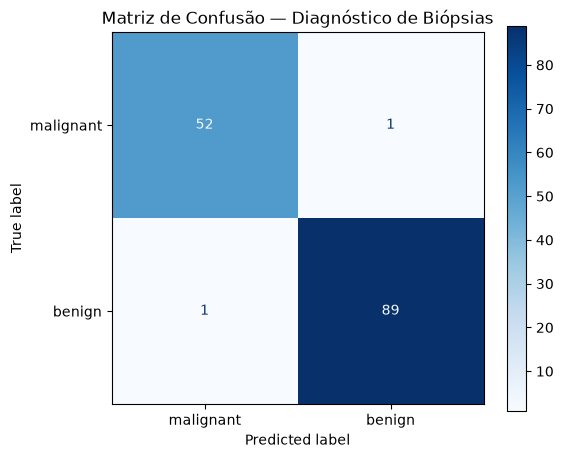

In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predições no conjunto de teste
y_pred_log = modelo_logistico.predict(X_test_scaled)

# 2. Exibimos o classification report formal
print("--- RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log, target_names=dados_cancer.target_names))

# 3. Plotamos a Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, 
    display_labels=dados_cancer.target_names, 
    cmap='Blues', 
    ax=ax
)
plt.title("Matriz de Confusão — Diagnóstico de Biópsias")
plt.grid(False)
plt.show()

---

## 🏆 Desafio Técnico de Validação
Gere a Matriz de Confusão para o modelo **KNN** e compare: qual dos dois modelos cometeu menos Falsos Negativos (casos malignos diagnosticados erroneamente como benignos)?

In [14]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
